In [2]:
# Make the shared utils.py importable, then mount storage.
# If running locally, utils.py just needs to sit in the same folder as this notebook.
import sys, os

RUNNING_IN_COLAB = 'google.colab' in str(get_ipython())

if RUNNING_IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/project/cv screening'
    os.makedirs(PROJECT_DIR, exist_ok=True)
    sys.path.append(PROJECT_DIR)
else:
    PROJECT_DIR = '.'

DATA_DIR = os.path.join(PROJECT_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)
print(f"PROJECT_DIR = {PROJECT_DIR}")
print(f"DATA_DIR    = {DATA_DIR}")

Mounted at /content/drive
PROJECT_DIR = /content/drive/MyDrive/project/cv screening
DATA_DIR    = /content/drive/MyDrive/project/cv screening/data


In [3]:
# !pip install kaggle
# !pip install -q -U python-dateutil wordcloud spacy sentence-transformers transformers einops tqdm kaggle
# !python -m spacy download en_core_web_sm -q


In [4]:
import re, ast, warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from datetime import datetime
from tqdm.notebook import tqdm
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

from utils import (clean_text, extract_city_state, safe_extract_list,
                   get_role_experience_years, compute_years_since_graduation,
                   parse_experience_range)

warnings.filterwarnings('ignore')
tqdm.pandas()
pd.set_option('display.max_colwidth', 120)

## Stage 1 — Ingest Data
Download the resume dataset from Kaggle and load it into a table.

In [5]:
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('username')
os.environ['KAGGLE_KEY']      = userdata.get('Key')

import kaggle
kaggle.api.dataset_download_files('saugataroyarghya/resume-dataset', unzip=True)

df = pd.read_csv('resume_data.csv')
print(f"Loaded -> {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head(3)


Dataset URL: https://www.kaggle.com/datasets/saugataroyarghya/resume-dataset
Loaded -> 9,544 rows, 35 columns


,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,﻿job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database warehouse manager with robust experience in handling all kinds of data. I ha...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning', 'Cloud', 'Hdfs', 'YARN', ...","['The Amity School of Engineering & Technology (ASET), Noida']",['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a reputed university.,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaboration\nDocumentation\nSystem Monitoring\nSoftware Deployment\nTraining &...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and junior data scientist. Experienced in creating meaningful data dashboa...,"['Data Analysis', 'Data Analytics', 'Business Analysis', 'R', 'SAS', 'PowerBi', 'Tableau', 'Data Visualization', 'Bu...","['Delhi University - Hansraj College', 'Delhi University - Hansraj College']","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in any relevant discipline from a reputed University,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional Collaboration\nStrategy Development\nML/NLP Infrastructure\nPrototype ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', 'Deep Learning', 'Risk Assessment', 'Requirement Gathering', 'Applicati...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, Hygiene Products",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, Sales Targets\nField Marketing, Campaigns, Product Distribution\nBrand ...",Brand Promotion\nCampaign Management\nField Supervision\nMerchandising\npromotional activities\nTrade Marketing,0.416667


## Stage 2 — Clean Data
Drop columns that carry no matching signal (raw URLs, cert issue/expiry dates),
drop rows with no skills listed, fill blanks with empty string rather than a
space, fix the hidden BOM character some CSV exports add to the first column
name, and normalise the free-text address into City, State.

In [6]:
columns_to_drop = ['company_urls', 'online_links', 'extra_curricular_organization_links',
                    'issue_dates', 'expiry_dates']
df = df.drop(columns=columns_to_drop, errors='ignore')

df.dropna(subset=['skills'], inplace=True)

text_cols = df.select_dtypes(include=['object']).columns
df[text_cols] = df[text_cols].fillna('')

df.rename(columns={c: c.replace('\ufeff', '') for c in df.columns}, inplace=True)
df['City_State'] = df['address'].apply(extract_city_state)

print(f"Shape after cleaning: {df.shape}")
display(df[['address', 'City_State']].head(3))

Shape after cleaning: (9488, 31)


,address,City_State
0,,Unknown
1,,Unknown
2,,Unknown


## Stage 3 — Work-History Experience
Turn the list-formatted job history (companies, start dates, end dates, roles)
into a single readable `CV_Job_History` text block and a `Total_Experience_Years`
number, by summing the duration of every role found.

In [8]:

def process_cv_experience(row):
    companies = safe_extract_list(row.get('professional_company_names', ''))
    starts    = safe_extract_list(row.get('start_dates', ''))
    ends      = safe_extract_list(row.get('end_dates', ''))
    roles     = safe_extract_list(row.get('positions', ''))
    resp = str(row.get('responsibilities', '')).replace('\n', ' ').strip()
    if resp.lower() in ('nan', 'none'):
        resp = ''

    job_blocks, past_roles, total_exp_years, num_companies = [], [], 0.0, 0
    for comp, st, en, role in zip(companies, starts, ends, roles):
        comp = comp if comp and str(comp) != 'None' else 'Unknown Company'
        role = role if role and str(role) != 'None' else 'Unknown Role'

        yrs = get_role_experience_years(st, en)

        if pd.isna(yrs):
            yrs = 0.0

        total_exp_years += yrs
        num_companies += 1
        job_blocks.append(f"[{comp} as {role} {yrs}yrs]")

        # Isolate the past job positions
        if role != 'Unknown Role':
            past_roles.append(role)

    history = ' '.join(job_blocks)
    if resp:
        history += f" [Responsibilities: {resp}]"

    # Join roles into a clean string for NLP
    past_job_positions = ' '.join(past_roles)

    return pd.Series([
        history.strip(),
        round(total_exp_years, 1),
        num_companies,
        past_job_positions
    ])

# Unpack 4 variables instead of 3
df[['CV_Job_History', 'Total_Experience_Years', 'Num_Companies', 'Past_Job_Positions']] = df.apply(process_cv_experience, axis=1)

## Stage 4 — Minimalist Experience Engineering & Penalty

**Effective Experience Calculation:** We use a hybrid approach to estimate experience.
- **Job-history based** — The sum of durations from `professional_company_names` / `start_dates` / `end_dates`. This is direct evidence and is preferred.
- **Graduation-year based** — `(Current Year − Degree Passing Year)`. Used only as a fallback proxy for candidates with zero recorded job history.

**Non-Linear Experience Penalty:**
We extract the `Min_Required_Years` from the job description. Instead of a simple gap, we apply a mathematical penalty (`Experience_Penalty`):
- If a candidate falls short of the minimum years (negative gap), the gap is **squared** to heavily penalize under-qualified candidates.
- If they meet or exceed the requirement (positive gap), the standard linear bonus is kept.

*(Note: Age proxies and "Preferred" experience years were explicitly removed to prevent ethical bias and mathematical multicollinearity in downstream ML models).*

In [9]:
# Extract ONLY the Minimum Required Experience
df['Min_Required_Years'] = df['experiencere_requirement'].apply(parse_experience_range).apply(lambda x: x[0])

# Compute Effective Experience (Fallback to graduation proxy if no job history)
CURRENT_YEAR = datetime.now().year

years_since_grad = df['passing_years'].apply(lambda v: compute_years_since_graduation(v, CURRENT_YEAR)) if 'passing_years' in df.columns else pd.Series(np.nan, index=df.index)

no_job_history = (df['Total_Experience_Years'] == 0) & (df['Num_Companies'] == 0)

df['Effective_Experience_Years'] = np.where(
    no_job_history & years_since_grad.notna(),
    years_since_grad,
    df['Total_Experience_Years']
).clip(max=40)

# Calculate Gap & Apply Non-Linear Penalty (Avoid saving intermediate gap to df)
# 3. Calculate Gap & Apply Non-Linear Penalty
exp_gap = df['Effective_Experience_Years'] - df['Min_Required_Years']
df['Experience_Penalty'] = np.where(exp_gap < 0, -(exp_gap ** 2), exp_gap).clip(-25, 40)

display(df[['Effective_Experience_Years', 'Min_Required_Years', 'Experience_Penalty']].head(8))

,Effective_Experience_Years,Min_Required_Years,Experience_Penalty
0,6.7,1.0,5.70
1,6.8,5.0,1.80
2,8.1,3.0,5.10
3,13.8,1.0,12.80
4,18.5,4.0,14.50
5,19.5,0.0,19.50
6,0.7,4.0,-10.89
7,20.5,4.0,16.50


## Stage 5 — Dynamic Context Flags
Read each row's job title and experience requirement and decide which extra
columns belong in that row's CV text. A fresher role pulls in extracurriculars
and career objective; an academic role pulls in the institution name; a
location-sensitive role pulls in the candidate's city.

In [10]:

ENTRY_KEYWORDS    = {'fresher', 'intern', 'entry', 'trainee', 'graduate', 'no experience'}
ACADEMIC_KEYWORDS = {'research', 'scientist', 'quant', 'professor', 'academic', 'statistician', 'analyst', 'phd'}
LOCATION_KEYWORDS = {'branch', 'warehouse', 'store', 'retail', 'field', 'driver', 'delivery', 'site', 'onsite'}

# Helper function to build strict word-boundary regex patterns
def build_word_pattern(keywords):
    """Compiles a regex pattern to match exact words, avoiding substring overlaps."""
    escaped_words = [re.escape(word) for word in keywords]
    return re.compile(r'\b(?:' + '|'.join(escaped_words) + r')\b')

# Compile patterns once globally for speed
entry_pattern    = build_word_pattern(ENTRY_KEYWORDS)
academic_pattern = build_word_pattern(ACADEMIC_KEYWORDS)
location_pattern = build_word_pattern(LOCATION_KEYWORDS)

# Define the tagging logic
def assign_role_flags(row):
    """Analyzes job descriptions and titles to assign role categories."""
    job_title = str(row.get('job_position_name', '')).lower()
    experience_req = str(row.get('experiencere_requirement', '')).lower()
    min_years = row.get('Min_Required_Years')

    # An entry-level role is triggered by either text keywords OR explicit numeric requirements (<= 1 year)
    is_entry_by_text = bool(entry_pattern.search(experience_req))
    is_entry_by_years = pd.notna(min_years) and (min_years <= 1)

    is_entry_role = is_entry_by_text or is_entry_by_years

    return pd.Series({
            'flag_entry_level'   : is_entry_role,
            'flag_academic'      : bool(academic_pattern.search(job_title)),
            'flag_location_role' : bool(location_pattern.search(job_title))
        })

flag_columns = ['flag_entry_level', 'flag_academic', 'flag_location_role']
df[flag_columns] = df.apply(assign_role_flags, axis=1)

display(df[flag_columns].sum().to_frame(name='Total Matches'))

,Total Matches
flag_entry_level,3391
flag_academic,0
flag_location_role,340


## Stage 6 — Build Master CV / JD Text (Redundancy Fixed)

`CV_COLS` below intentionally does **not** include `positions` or
`role_positions`. Both used to be concatenated directly into the CV text on
top of `CV_Job_History`, which already states every role inline as
`"[Company as Role X.Xyrs]"`. Keeping all three meant every job title a
candidate held was counted two or three times over in the TF-IDF vocabulary,
silently inflating how much weight title words got relative to skills,
certifications, and other genuinely distinct information. `CV_Job_History` is
now the single source of role/title text.

In [11]:
CV_COLS = [
    'CV_Job_History', 'responsibilities','degree_names','major_field_of_studies',
    'skills', 'related_skils_in_job', 'certification_skills','languages'
]
JD_COLS = ['job_position_name', 'skills_required', 'responsibilities.1',
           'educationaL_requirements' ] #'experiencere_requirement'

def build_master_texts(row):
    """Dynamically builds the Master text blocks based on role flags."""
    cv_cols, jd_cols = list(CV_COLS), list(JD_COLS)

    if row.get('flag_entry_level'):
        cv_cols += ['extra_curricular_activity_types', 'extra_curricular_organization_names',
                    'educational_results', 'result_types', 'career_objective'] # Consolidated narrative logic here
    if row.get('flag_academic'):
        cv_cols += ['educational_institution_name']
    if row.get('flag_location_role'):
        cv_cols += ['City_State', 'locations']

    # Filter out columns that aren't in the index
    valid_cv = [c for c in cv_cols if c in row.index]
    valid_jd = [c for c in jd_cols if c in row.index]

    # CRITICAL FIX: Only stringify if the value is not NaN to prevent literal "nan" text injections
    cv_text = re.sub(r'\s+', ' ', ' '.join(str(row[c]) for c in valid_cv if pd.notna(row[c]))).strip()
    jd_text = re.sub(r'\s+', ' ', ' '.join(str(row[c]) for c in valid_jd if pd.notna(row[c]))).strip()

    return pd.Series({'Master_CV_Text': cv_text, 'Master_JD_Text': jd_text})


df[['Master_CV_Text', 'Master_JD_Text']] = df.apply(build_master_texts, axis=1)

keep_columns = [
    'matched_score', 'Effective_Experience_Years',
    'Min_Required_Years', 'Experience_Penalty',
    'career_objective', 'responsibilities.1', 'job_position_name' ,
    'Master_CV_Text', 'Master_JD_Text',
    'Cosine_TFIDF', 'Cosine_Semantic' # Cosine_Hybrid safely removed ,'Min_Required_Years' , 'Experience_Tier', 'Implied_Age',
] + flag_columns

df_final = df[[c for c in keep_columns if c in df.columns]].copy()
print("df_final shape:", df_final.shape)


df_final shape: (9488, 12)


## Stage 7 — Deduplicate & Filter by Word Count
Exact duplicate CVs are removed to prevent the same example ending up in both
the training and test sets later. CVs under 20 or over 350 words are outliers
— too little text to match on, or a raw data dump — and are dropped.

In [12]:
# Deduplicate on the specific CV-to-JD pairing, not just the CV
n_dups = df_final.duplicated(subset=['Master_CV_Text', 'Master_JD_Text']).sum()
df_final = df_final.drop_duplicates(subset=['Master_CV_Text', 'Master_JD_Text'])

df_final['CV_Word_Count'] = df_final['Master_CV_Text'].apply(lambda x: len(str(x).split()))
df_filtered = df_final[df_final['CV_Word_Count'].between(20, 350)].copy()

print(f"Removed {n_dups} duplicate pairings, {len(df_final)-len(df_filtered)} word-count outliers")
print(f"Remaining rows: {len(df_filtered):,}")

Removed 0 duplicate pairings, 119 word-count outliers
Remaining rows: 9,369


## Stage 8 — NLP Cleaning
`clean_text` is imported from `utils.py` — the exact same function that
`03_prediction.ipynb` will call on new CVs later, so training and prediction
never see differently-cleaned text.

In [ ]:
df_filtered['Processed_CV'] = df_filtered['Master_CV_Text'].progress_apply(clean_text)
df_filtered['Processed_JD'] = df_filtered['Master_JD_Text'].progress_apply(clean_text)

df_model = df_filtered[
    df_filtered['Processed_CV'].str.strip().astype(bool) &
    df_filtered['Processed_JD'].str.strip().astype(bool)
].copy()
print(f"Rows after NLP cleaning: {len(df_model):,}")
display(df_model[['Processed_CV', 'Processed_JD']].head(2))


  0%|          | 0/9369 [00:00<?, ?it/s]

  0%|          | 0/9369 [00:00<?, ?it/s]

Rows after NLP cleaning: 9,369


,Processed_CV,Processed_JD
0,coca cola big data analyst yrs technical support troubleshoot collaboration documentation system monitor software de...,senior software engineer technical support troubleshoot collaboration documentation system monitor software deployme...
1,bib consultancy business analyst yrs machine learn leadership cross functional collaboration strategy development ml...,machine learning ml engineer machine learn leadership cross functional collaboration strategy development ml nlp inf...


## Stage 9 — EDA: Word Cloud & Top Terms
A quick visual sanity check that the cleaned vocabulary looks like real skills
and role terms, not leftover filler.

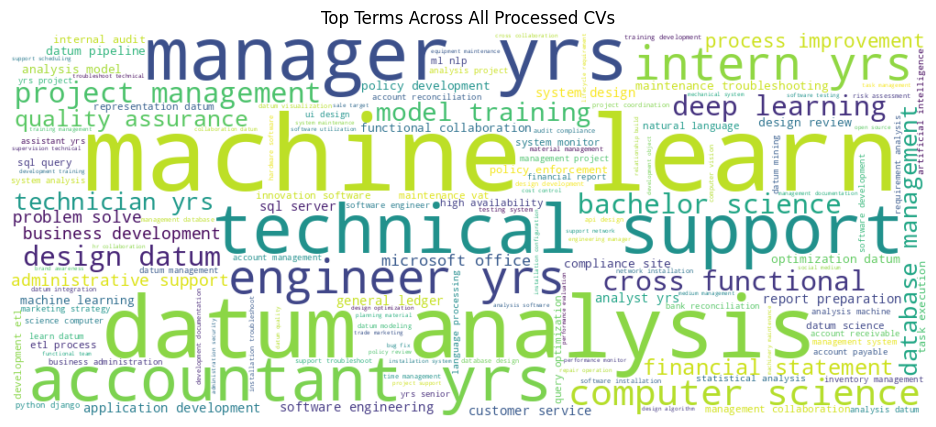

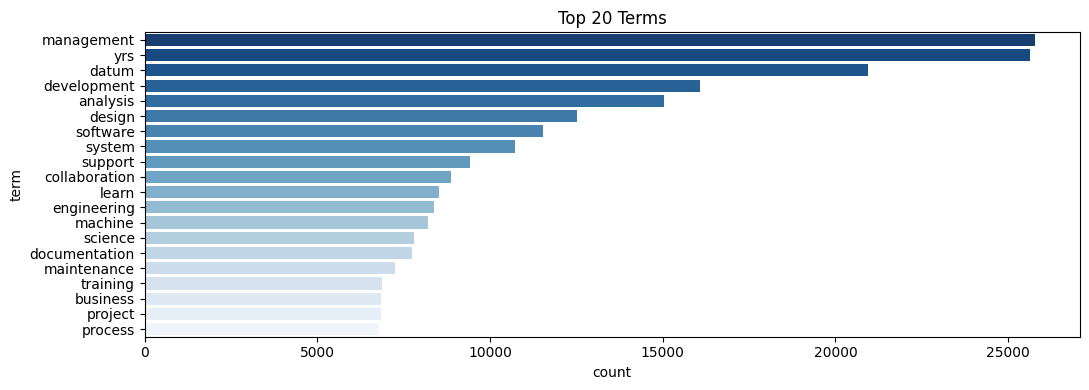

In [ ]:
all_cv_text = ' '.join(df_model['Processed_CV'].dropna())
wc = WordCloud(width=1000, height=420, background_color='white', colormap='viridis', max_words=150).generate(all_cv_text)
plt.figure(figsize=(14, 5)); plt.imshow(wc, interpolation='bilinear'); plt.axis('off')
plt.title('Top Terms Across All Processed CVs'); plt.show()

count_vec = CountVectorizer(max_features=20, ngram_range=(1, 2))
X_counts  = count_vec.fit_transform(df_model['Processed_CV'])
freq_df   = pd.DataFrame({'term': count_vec.get_feature_names_out(),
                          'count': X_counts.toarray().sum(axis=0)}).sort_values('count', ascending=False)
plt.figure(figsize=(11, 4)); sns.barplot(data=freq_df, x='count', y='term', palette='Blues_r')
plt.title('Top 20 Terms'); plt.tight_layout(); plt.show()


## Stage 10 — Vectorisation: TF-IDF (Keyword Matching)
Fit on CV and JD text together so both live in the same vocabulary space —
required for a valid cosine similarity comparison later.

In [ ]:
# Vectorisation: TF-IDF (Fit on entire corpus for ATS indexing)
tfidf = TfidfVectorizer(stop_words='english', max_features=8000, ngram_range=(1, 3),
                         sublinear_tf=True, min_df=2)
combined_text = pd.concat([df_model['Processed_CV'], df_model['Processed_JD']]).fillna('')
tfidf.fit(combined_text)

cv_tfidf = tfidf.transform(df_model['Processed_CV'].fillna(''))
jd_tfidf = tfidf.transform(df_model['Processed_JD'].fillna(''))
print(f"CV TF-IDF: {cv_tfidf.shape}   JD TF-IDF: {jd_tfidf.shape}")

CV TF-IDF: (9369, 8000)   JD TF-IDF: (9369, 8000)


## Stage 11 — Vectorisation: SBERT (Semantic Meaning)
TF-IDF only sees exact keyword overlap. SBERT captures meaning, so "software
developer" and "software engineer" score as similar even though they share
no keyword. Encoded on the raw `Master_*_Text`, not the lemmatised
`Processed_*` text — SBERT needs natural sentence structure to work well.

In [ ]:
import torch
assert torch.cuda.is_available(), "GPU not found! Please check your Colab runtime settings."

In [ ]:
# The model will now download incredibly fast, and only has to do it once.
sbert = SentenceTransformer('nomic-ai/nomic-embed-text-v1.5', trust_remote_code=True)

cv_prefixed = ['search_document: ' + str(text) for text in df_model['Master_CV_Text'].tolist()]
jd_prefixed = ['search_query: ' + str(text) for text in df_model['Master_JD_Text'].tolist()]

# Increased batch size to 64 to fully utilize the T4 GPU
cv_dense = sbert.encode(cv_prefixed, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
jd_dense = sbert.encode(jd_prefixed, batch_size=64, show_progress_bar=True, normalize_embeddings=True)

print(f"CV dense: {cv_dense.shape} | JD dense: {jd_dense.shape}")

In [ ]:
torch.cuda.empty_cache()

## Stage 12 — Similarity Features
`Cosine_TFIDF` and `Cosine_Semantic` are kept as two separate columns rather
than blended into one. Blending them (e.g. `0.4*tfidf + 0.6*semantic`) creates
a column that is a fixed linear combination of the other two, which causes
multicollinearity if you ever run a linear model on these features — see the
VIF check in `02_modeling.ipynb`. Keeping them separate lets the model learn
its own weighting instead of one being forced on it here.

`Cosine_Objective_Fit` compares the candidate's stated `career_objective`
against the JD's `responsibilities.1`. This field is usually only filled in
for entry-level candidates (see Stage 5's `flag_narrative`), so a
`Has_Career_Objective`-aware neutral fill is used: experienced candidates who
never wrote an objective are not penalised for a blank field.

In [ ]:


df_model['Cosine_TFIDF']    = np.asarray(cv_tfidf.multiply(jd_tfidf).sum(axis=1)).ravel()
df_model['Cosine_Semantic'] = (cv_dense * jd_dense).sum(axis=1)


In [ ]:
from sklearn.linear_model import LinearRegression

X = df_model[['Cosine_Semantic', 'Cosine_TFIDF']]
y = df_model['matched_score']

ols_model = LinearRegression()
ols_model.fit(X, y)

intercept = ols_model.intercept_
weight_semantic = ols_model.coef_[0]
weight_tfidf = ols_model.coef_[1]

print(f"Optimal Intercept:       {intercept:.4f}")
print(f"Optimal Semantic Weight: {weight_semantic:.4f}")
print(f"Optimal TF-IDF Weight:   {weight_tfidf:.4f}\n")

df_model['Cosine_Hybrid'] = (
    intercept +
    (weight_semantic * df_model['Cosine_Semantic']) +
    (weight_tfidf * df_model['Cosine_TFIDF'])
)

In [ ]:

# Objective Fit (Neutral Fill)
has_objective = (df_model['career_objective'].str.strip().astype(bool) &
                 df_model['responsibilities.1'].str.strip().astype(bool))

df_model['Cosine_Objective_Fit'] = np.nan
obj_texts  = df_model.loc[has_objective, 'career_objective'].tolist()
resp_texts = df_model.loc[has_objective, 'responsibilities.1'].tolist()

if obj_texts:
    obj_emb  = sbert.encode(obj_texts,  batch_size=64, show_progress_bar=True, normalize_embeddings=True)
    resp_emb = sbert.encode(resp_texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
    df_model.loc[has_objective, 'Cosine_Objective_Fit'] = (obj_emb * resp_emb).sum(axis=1)

# Fill missing objectives with the dataset mean
mean_fit = df_model.loc[has_objective, 'Cosine_Objective_Fit'].mean() if has_objective.any() else 0.5
df_model['Cosine_Objective_Fit'] = df_model['Cosine_Objective_Fit'].fillna(mean_fit)

# Clean target variable and print safe correlations
df_model['matched_score'] = df_model['matched_score'].astype(str).str.replace('%', '').astype(float)

df_model['Semantic_x_Experience'] = df_model['Cosine_Semantic'] * df_model['Effective_Experience_Years']


## Stage 13 — Save Processed Data & Models


In [ ]:
final_ml_columns = [
    'job_position_name',
    'matched_score',              # TARGET VARIABLE
    'Cosine_TFIDF',               # REQUIRED FOR COMPARISON
    'Cosine_Semantic',            # REQUIRED FOR COMPARISON
    'Cosine_Hybrid',              # REQUIRED FOR COMPARISON
    'Cosine_Objective_Fit',       # Objective/Responsibility fit
    'Effective_Experience_Years', # Hard HR requirement
    'Semantic_x_Experience',      # Synergistic interaction term
    'flag_entry_level',            # The only flag that showed predictive weight
    'Processed_CV',
    'Processed_JD'
]

df_ml_ready = df_model[final_ml_columns].copy()
df_ml_ready['Experience_Penalty'] = df['Experience_Penalty']

# Ensure no NaNs leaked through to crash the regression models later
df_ml_ready = df_ml_ready.dropna()

print(f"Final ML dataset shape: {df_ml_ready.shape}")
display(df_ml_ready.head(3))

In [ ]:

df_ml_ready.to_csv(f'{DATA_DIR}/ml_ready_dataset.csv', index=False)

sp.save_npz(f'{DATA_DIR}/cv_tfidf.npz', cv_tfidf)
sp.save_npz(f'{DATA_DIR}/jd_tfidf.npz', jd_tfidf)

np.save(f'{DATA_DIR}/cv_dense.npy', cv_dense)
np.save(f'{DATA_DIR}/jd_dense.npy', jd_dense)

joblib.dump(tfidf, f'{DATA_DIR}/tfidf_vectorizer.pkl')
joblib.dump(mean_fit, f'{DATA_DIR}/objective_fit_neutral_value.pkl')